
# Foundations of Machine Learning: An Introduction to Neural Networks & MLPs
This notebook is a tutorial on **Neural Networks**. It starts with the basic building block, the "neuron," and builds its way up to a more powerful model capable of solving complex problems: the **Multi-Layered Perceptron (MLP)**.

At the end is a workshop on classifying handwritten digits from the MNIST dataset.

You will be asked to compare the Keras, PyTorch and TensorFlow implementations in terms of accuracy and speed.

<br/>
<br/>

### 💡 Additional Reading Material

These other tutorials come from the Course Notebooks Repository:

> In-depth: 
[**Multiclass Classification - A Simple Keras Model (MNIST)**](https://github.com/CSCN8010/CSCN8010/blob/main/dl_class_notebooks/03A_minimal_mnist_keras.ipynb)

> In-depth: 
[**Train and Aave a Simple Keras Model (MNIST)**](https://github.com/CSCN8010/CSCN8010/blob/main/dl_class_notebooks/03D_keras_checkpoints_save_model.ipynb)

> In-depth: 
[**Loading a pre-trained Keras model and classifying digits (MNIST)**](https://github.com/CSCN8010/CSCN8010/blob/main/dl_class_notebooks/03B_load_minimal_mnist_model.ipynb)  

<br/>
<br/>

***



### 1. The Inspiration: From Biological to Artificial Neurons

At its core, the field of neural networks is inspired by the human brain. We'll start by understanding the basic concept of a neuron.

#### **Key Concepts: The Neuron**

- An artificial intelligence (AI) system is designed to perceive its environment and act accordingly. 
- Neural networks are the "brain" of these systems.
- The simplest neural network is a **perceptron**, which consists of a single artificial neuron.
- The concept of an artificial neuron is modeled after a biological one.

* A **biological neuron** receives electrical signals through its *dendrites*. If the combined strength of these signals surpasses a certain threshold, the neuron "fires," sending an output signal through its *synapses* to other neurons.
* An **artificial neuron** works similarly. It receives multiple *inputs*, performs a calculation, and if the result exceeds a threshold, it produces an *output*.



### 2. The Perceptron: A Single Neuron in Action

Let's break down the mechanics of that single artificial neuron, the perceptron.

#### **Presentation: Anatomy of a Perceptron**

A perceptron operates on a simple principle: it takes a set of inputs, weighs them based on their importance, sums them up, and then uses an **activation function** to decide whether to "fire" and produce an output.

Here are the key components:

1.  **Inputs ($x$)**: These are the features of your data. For example, if you're predicting a house price, inputs could be the size, number of rooms, and age of the house. Each input is a feature that contributes to the final decision.

2.  **Weights ($w$)**: Not all inputs are equally important. Each input feature ($x_i$) is assigned a weight ($w_i$) that reflects its importance in the decision-making process. A higher weight amplifies an input's effect, while a lower weight diminishes it. The network learns these weights during training.

3.  **Weighted Sum ($z$)**: The neuron calculates the sum of all inputs multiplied by their corresponding weights. We also add a **bias ($b$)**, which is like the y-intercept in a linear equation. It allows us to shift the activation function, giving the model more flexibility. The formula is:
    $$z = (x_1w_1 + x_2w_2 + ... + x_nw_n) + b = \sum_{i=1}^{n} x_i w_i + b$$

4.  **Activation Function ($f(z)$)**: This is the decision-making unit of the neuron. It takes the weighted sum ($z$) as input and transforms it into the final output. For a simple step function, the output is either 0 or 1. This introduces non-linearity, which is crucial for learning complex patterns.



#### **Building a Perceptron with Python**

Let's build a simple perceptron from scratch using NumPy to see these concepts in code. We'll use a simple "step" activation function.


In [7]:
import numpy as np

# A simple perceptron class
class Perceptron:
    """A single neuron model."""

    def __init__(self, num_inputs):
        """
        Initializes the perceptron.
        Args:
            num_inputs (int): The number of input features.
        """
        # Initialize weights with small random numbers. Bias is the last weight.
        self.weights = np.random.rand(num_inputs + 1)
        print(f"Initialized weights: {self.weights}")

    def step_function(self, z):
        """The activation function."""
        return 1 if z >= 0 else 0

    def predict(self, inputs):
        """
        Calculates the weighted sum and passes it to the activation function.
        Args:
            inputs (list or np.array): The input features.
        Returns:
            int: The binary output (0 or 1).
        """
        # Add the bias input (always 1)
        inputs_with_bias = np.append(inputs, 1)

        # Calculate the weighted sum: z = sum(x_i * w_i)
        z = np.dot(inputs_with_bias, self.weights)
        print(f"Inputs (with bias): {inputs_with_bias}")
        print(f"Weighted Sum (z): {z:.4f}")

        # Apply the activation function
        output = self.step_function(z)
        print(f"Output: {output}")
        return output

# --- Let's test our Perceptron! ---
# Create a perceptron that takes 2 inputs
p = Perceptron(num_inputs=2)

# Define some sample inputs
sample_inputs = np.array([0.8, 0.5])

# Make a prediction
prediction = p.predict(sample_inputs)
print(f"\nFinal prediction for inputs {sample_inputs} is: {prediction}")


Initialized weights: [0.77127035 0.07404465 0.35846573]
Inputs (with bias): [0.8 0.5 1. ]
Weighted Sum (z): 1.0125
Output: 1

Final prediction for inputs [0.8 0.5] is: 1



### 3. Activation Functions: Adding Non-Linearity

[cite_start]A single perceptron with a step function can only separate data with a single straight line[cite: 178]. To learn truly complex patterns, like those in images or speech, we need more sophisticated activation functions that introduce **non-linearity**.

#### **Presentation: Common Activation Functions**

While there are many activation functions, three are particularly common and important to know. [cite_start]The PDF specifically mentions **ReLU** and **softmax** as popular choices[cite: 280].

1.  **Sigmoid (or Logistic)**
    * **Formula**: $\sigma(z) = \frac{1}{1 + e^{-z}}$
    * **Output Range**: (0, 1)
    * **Use Case**: Excellent for binary classification problems where the output needs to be a probability.
    * **Downside**: Suffers from the "vanishing gradient" problem, which can slow down learning in deep networks.

2.  **Tanh (Hyperbolic Tangent)**
    * **Formula**: $\tanh(z) = \frac{e^z - e^{-z}}{e^z + e^{-z}}$
    * **Output Range**: (-1, 1)
    * **Use Case**: Similar to sigmoid but is "zero-centered," which can sometimes help models learn faster.
    * **Downside**: Also suffers from the vanishing gradient problem.

3.  **ReLU (Rectified Linear Unit)**
    * **Formula**: $R(z) = \max(0, z)$
    * **Output Range**: [0, $\infty$)
    * **Use Case**: The most popular activation function for hidden layers in deep learning. It's computationally very efficient and helps mitigate the vanishing gradient problem.
    * **Downside**: Can "die" if a neuron's output consistently becomes zero, preventing weight updates.



#### **Visualizing Activation Functions**

Let's plot these functions to understand their behavior.


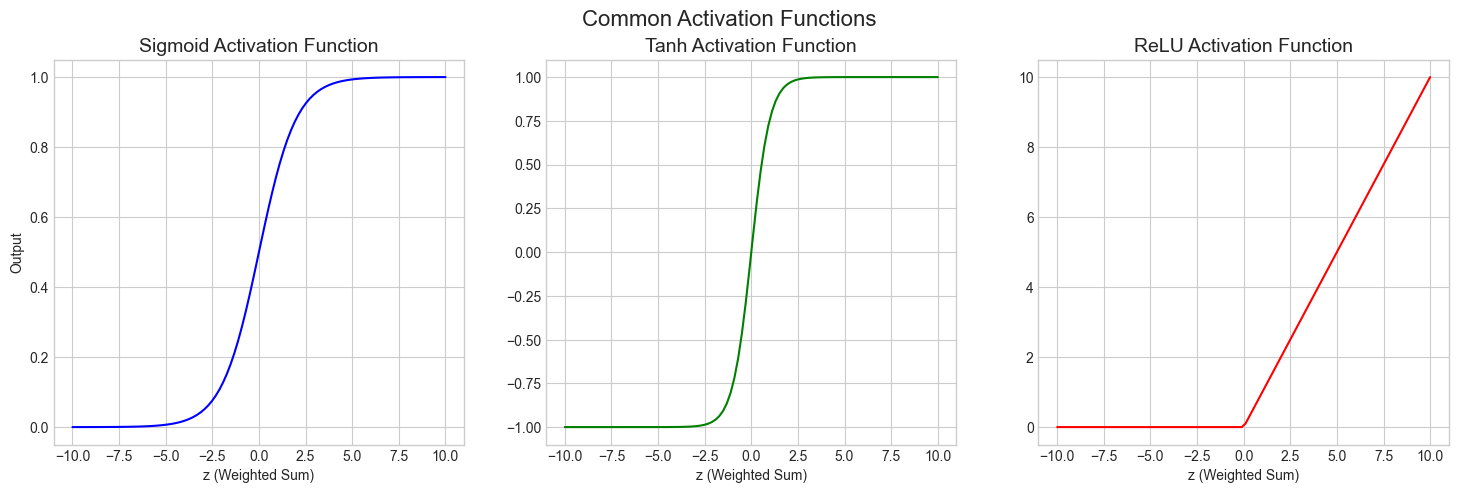

In [8]:

import numpy as np
import matplotlib.pyplot as plt

# Define the input range
z = np.linspace(-10, 10, 100)

# Define the activation functions
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def tanh(x):
    return np.tanh(x)

def relu(x):
    return np.maximum(0, x)

# Plotting
plt.style.use('seaborn-v0_8-whitegrid')
fig, axs = plt.subplots(1, 3, figsize=(18, 5))

axs[0].plot(z, sigmoid(z), color='blue')
axs[0].set_title('Sigmoid Activation Function', fontsize=14)
axs[0].set_xlabel('z (Weighted Sum)')
axs[0].set_ylabel('Output')

axs[1].plot(z, tanh(z), color='green')
axs[1].set_title('Tanh Activation Function', fontsize=14)
axs[1].set_xlabel('z (Weighted Sum)')

axs[2].plot(z, relu(z), color='red')
axs[2].set_title('ReLU Activation Function', fontsize=14)
axs[2].set_xlabel('z (Weighted Sum)')

plt.suptitle('Common Activation Functions', fontsize=16)
plt.show()



### 4. From One to Many: The Multi-Layer Perceptron (MLP)

A single neuron is limited. To solve complex, **non-linear problems**, we need to combine many neurons into a network.

#### **MLP Architecture**

A very common architecture is to stack neurons in layers. This creates a **Multi-Layer Perceptron (MLP)**. An MLP has three types of layers:

1.  **Input Layer**: This layer receives the initial feature vector. It doesn't perform calculations; it simply passes the data to the first hidden layer.
2.  **Hidden Layers**: These are the layers between the input and output. This is where most of the learning happens. Each neuron in a hidden layer receives outputs from the previous layer, performs the `weighted sum -> activation` calculation, and passes its output to the next layer. Networks with two or more hidden layers are often called **deep neural networks**.
3.  **Output Layer**: This is the final layer that produces the model's prediction. The number of neurons and the activation function in this layer depend on the problem you're solving (e.g., one neuron with a sigmoid for binary classification, or multiple neurons with a softmax function for multi-class classification).

In an MLP, layers are typically **fully connected**, meaning every neuron in one layer is connected to every neuron in the next layer.



### 5. The Learning Process: Feedforward & Backpropagation

How does an MLP actually *learn*? It's a two-part process that is repeated many times: **Feedforward** to make a prediction, and **Backpropagation** to correct errors.

#### **The Learning Loop**

**Step 1: Feedforward (Making a Prediction)**

This is the process of information flowing forward through the network.

1.  The input data is fed into the **input layer**.
2.  The data flows to the first **hidden layer**. Each neuron in this layer calculates its weighted sum and applies its activation function.
3.  The outputs of the first hidden layer become the inputs for the second hidden layer, and so on.
4.  This continues until the data reaches the **output layer**, which produces the final prediction ($y'$).

The entire process is a chain of `weighted sum -> activation` calculations, layer by layer, from input to output.

**Step 2: Backpropagation (Learning from Mistakes)**

Once the network makes a prediction ($y'$), we need to see how good it was.

1.  **Compute Error (Loss)**: We compare the network's prediction ($y'$) with the correct, true label ($y$). The difference is the **error**. We use an **error function** (or loss function) like Mean Squared Error or Cross-Entropy to calculate a single score representing how wrong the model was.
    * **Error Calculation**: `error = y - y'` 

2.  **Propagate Error Backwards**: This is the magic of backpropagation. The error is sent backward through the network, from the output layer to the input layer.

3.  **Update Weights**: As the error propagates back, it's used to calculate how much each weight and bias in the network contributed to the total error. The network then adjusts its weights to reduce the error. For instance, if a large weight led to a large error, the network will decrease that weight. This process uses calculus (specifically, an algorithm called **gradient descent**) to find the optimal weight values that minimize the error. For a more in-depth analysis of this method, read the tutorial at [3Blue1Brown - What is Backpropagation Really Doing?](https://www.3blue1brown.com/lessons/backpropagation)

4.  **Repeat**: This entire `feedforward -> backpropagation` cycle is repeated many times (for many **epochs**) with the entire training dataset. With each cycle, the network's weights get a little bit better, and its predictions become more and more accurate.


## 🔄 Understanding How the Model Compares Predictions to True Labels (Backpropagation Step 2)

During training, your model learns by comparing its **predicted output** to the **correct, true label** that comes from the dataset. This comparison happens **during every epoch**, and it is essential for calculating the **loss** (error), which drives backpropagation.

### ✅ What Happens During Training (Simplified View)

1. **Training Dataset**  
   You start with a dataset consisting of input–output pairs:  
   $$
   (X, y) = \\{(x^{(1)}, y^{(1)}), (x^{(2)}, y^{(2)}), ..., (x^{(n)}, y^{(n)})\\}
   $$
   - $x^{(i)}$ is the input vector (features)
   - $y^{(i)}$ is the correct, true label (target output)

2. **Model Initialization**  
   The model starts with **random weights**.

3. **Epoch Loop**  
   For each epoch:
   - For each mini-batch or training sample:
     1. Feed **input `x`** into the model → get prediction `y_pred`
     2. Compare `y_pred` with the **true label `y_true`**
     3. Compute **loss** using a loss function (e.g., MSE or Cross-Entropy)
     4. Perform **backpropagation** to compute gradients
     5. **Update weights** with an optimizer

### 🧠 Pseudocode: Training Up to Loss Calculation

```python
# Assume: training_data = [(x1, y1), (x2, y2), ..., (xn, yn)]
# x = input vector, y = true label

initialize_model_weights()

for epoch in range(num_epochs):
    for x, y_true in training_data:
        
        # ---- FEEDFORWARD ----
        y_pred = model.forward(x)  # Predict output based on current weights
        
        # ---- COMPARE PREDICTION TO TRUE LABEL ----
        # Step 1: Compute loss (error between prediction and true label)
        loss = loss_function(y_pred, y_true)  # e.g., MSE, Cross-Entropy

        # ---- BACKPROPAGATION ----
        gradients = compute_gradients(loss, model.weights)
        
        # ---- UPDATE WEIGHTS ----
        optimizer.step(model.weights, gradients)
````

### 💬 Where Does `y_true` Come From?

It comes from the **training dataset**, which:

* Is usually prepared as `(X_train, y_train)` arrays
* Or loaded using a **DataLoader** that returns `(x, y)` pairs

During training, for every training example or batch:

* The model uses the **input `x`** to make a prediction
* The **label `y_true`** is passed into the **loss function** to compute how wrong the prediction was


### 🎓 Example (PyTorch Training Loop)

```python
for x_batch, y_true in train_loader:
    y_pred = model(x_batch)                  # Forward pass
    loss = loss_fn(y_pred, y_true)           # Compare prediction to true label
    loss.backward()                          # Backpropagation
    optimizer.step()                         # Update weights
    optimizer.zero_grad()                    # Reset gradients
```

### 📝 To summarize...

* The **true label `y_true`** comes from the training dataset.
* It is compared to the **model’s prediction `y_pred`** inside the loss function.
* The result (error/loss) is backpropagated to update weights and improve predictions.




### 6. Building an MLP: The Complete Workshop

Now, let's put it all together. We will build, train, and evaluate an MLP to solve a classic machine learning problem: classifying handwritten digits from the MNIST dataset. We'll use the three most popular deep learning libraries: **Keras (with a TensorFlow backend)**, **TensorFlow (Core API)**, and **PyTorch**.

This will show you that while the syntax differs, the core concepts�defining layers, choosing a loss function, and training the model�are universal.

#### **Code Workshop: MNIST Digit Classification**

First, let's load and prepare our data.


In [9]:
import time
import tensorflow as tf
from tensorflow import keras
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
import numpy as np
import matplotlib.pyplot as plt

# --- Load and Preprocess Data ---
# Load data for TensorFlow/Keras
(x_train_tf, y_train_tf), (x_test_tf, y_test_tf) = keras.datasets.mnist.load_data()

# Normalize pixel values to be between 0 and 1
x_train_tf = x_train_tf.astype("float32") / 255.0
x_test_tf = x_test_tf.astype("float32") / 255.0

# Flatten the images from 28x28 to 784-element vectors
x_train_flat = x_train_tf.reshape(-1, 784)
x_test_flat = x_test_tf.reshape(-1, 784)

print(f"TensorFlow/Keras Data Shape: {x_train_flat.shape}")

# Load data for PyTorch
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

train_dataset_pt = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
test_dataset_pt = datasets.MNIST(root='./data', train=False, download=True, transform=transform)

train_loader_pt = torch.utils.data.DataLoader(train_dataset_pt, batch_size=64, shuffle=True)
test_loader_pt = torch.utils.data.DataLoader(test_dataset_pt, batch_size=64, shuffle=False)

print(f"PyTorch Data Loaded. Number of training batches: {len(train_loader_pt)}")


TensorFlow/Keras Data Shape: (60000, 784)
PyTorch Data Loaded. Number of training batches: 938



#### **Implementation 1: Keras**

Keras is popular due to its simplicity and user-friendly API. 

> Note the time spent training the model. 

- Tweak the hyperparameters to and test their impact on training speed.
- Analyze the training metrics (on the output). What are `val_accuracy` and `val_loss` ?


In [10]:
# --- 1. Define the Keras Model ---
# This is a sequential model, a simple stack of layers.
model_keras = keras.Sequential([
    keras.layers.Input(shape=(784,)),
    keras.layers.Dense(128, activation='relu'),
    keras.layers.Dense(64, activation='relu'),
    keras.layers.Dense(10, activation='softmax')
])

# Print a summary of the model architecture
model_keras.summary()

# --- 2. Compile the Model ---
model_keras.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# --- 3. Train the Model ---
print("\n--- Training Keras Model ---")
keras_start_time = time.perf_counter()

history = model_keras.fit(
    x_train_flat,
    y_train_tf,
    batch_size=64,
    epochs=5,
    validation_split=0.1,
    verbose=1
)

keras_training_time = time.perf_counter() - keras_start_time

# --- 4. Evaluate the Model ---
print("\n--- Evaluating Keras Model ---")
keras_test_loss, keras_test_acc = model_keras.evaluate(x_test_flat, y_test_tf, verbose=2)
print(f"\nKeras Test Accuracy: {keras_test_acc:.4f}")
print(f"Keras Training Time (seconds): {keras_training_time:.2f}")

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_6 (Dense)                 │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,386 (427.29 KB)

 Trainable params: 109,386 (427.29 KB)

 Non-trainable params: 0 (0.00 B)


--- Training Keras Model ---
Epoch 1/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9171 - loss: 0.2872 - val_accuracy: 0.9620 - val_loss: 0.1230
Epoch 2/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9639 - loss: 0.1213 - val_accuracy: 0.9743 - val_loss: 0.0859
Epoch 3/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9746 - loss: 0.0829 - val_accuracy: 0.9775 - val_loss: 0.0773
Epoch 4/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9804 - loss: 0.0634 - val_accuracy: 0.9778 - val_loss: 0.0809
Epoch 5/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9853 - loss: 0.0465 - val_accuracy: 0.9770 - val_loss: 0.0803

--- Evaluating Keras Model ---
313/313 - 0s - 1ms/step - accuracy: 0.9760 - loss: 0.0781

Keras Test Accuracy: 0.9760
Keras Training Time (seconds): 13.44



#### **Implementation 2: PyTorch**

PyTorch is known for its flexibility and is very popular in research. The structure is more explicit, requiring you to define the model as a class. 

> Note the time spent training the model. 

- Tweak the hyperparameters to and test their impact on training speed.
- Analyze the code. What are `images`, `labels`, `criterion` and `optimizer` ?


In [11]:
# --- 1. Define the PyTorch Model ---
class MLP_PyTorch(nn.Module):
    def __init__(self):
        super(MLP_PyTorch, self).__init__()
        self.flatten = nn.Flatten()
        self.layers = nn.Sequential(
            nn.Linear(28 * 28, 128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, 10)
        )

    def forward(self, x):
        x = self.flatten(x)
        logits = self.layers(x)
        return logits

model_pt = MLP_PyTorch()
print(model_pt)

# --- 2. Define Loss and Optimizer ---
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model_pt.parameters(), lr=0.001)

# --- 3. Train the Model ---
print("\n--- Training PyTorch Model ---")
pt_start_time = time.perf_counter()
model_pt.train()

for epoch in range(5):
    running_loss = 0.0
    for images, labels in train_loader_pt:
        optimizer.zero_grad()
        outputs = model_pt(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()

    print(f"Epoch {epoch + 1}, Loss: {running_loss / len(train_loader_pt):.4f}")

pt_training_time = time.perf_counter() - pt_start_time

# --- 4. Evaluate the Model ---
print("\n--- Evaluating PyTorch Model ---")
model_pt.eval()
correct = 0
total = 0

with torch.no_grad():
    for images, labels in test_loader_pt:
        outputs = model_pt(images)
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

pt_test_acc = correct / total
print(f"PyTorch Test Accuracy: {pt_test_acc:.4f}")
print(f"PyTorch Training Time (seconds): {pt_training_time:.2f}")

MLP_PyTorch(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (layers): Sequential(
    (0): Linear(in_features=784, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=64, bias=True)
    (3): ReLU()
    (4): Linear(in_features=64, out_features=10, bias=True)
  )
)

--- Training PyTorch Model ---
Epoch 1, Loss: 0.3900
Epoch 2, Loss: 0.1856
Epoch 3, Loss: 0.1323
Epoch 4, Loss: 0.1069
Epoch 5, Loss: 0.0918

--- Evaluating PyTorch Model ---
PyTorch Test Accuracy: 0.9685
PyTorch Training Time (seconds): 101.45



#### **Implementation 3: TensorFlow (Core API)**

This shows how to build a model using the core TensorFlow 2.x API, which is more verbose than Keras but offers more control.

> Note the time spent training the model. 

- Tweak the hyperparameters to and test their impact on training speed.
- Analyze the training metrics (on the output). What are `@tf.function`, `loss_object` and `optimizer_tf` ?


In [12]:
# Using the data we already loaded and flattened for Keras
train_dataset_tf = tf.data.Dataset.from_tensor_slices((x_train_flat, y_train_tf)).shuffle(60000).batch(64)
test_dataset_tf = tf.data.Dataset.from_tensor_slices((x_test_flat, y_test_tf)).batch(64)

# --- 1. Define the TensorFlow Model ---
class MLP_TensorFlow(tf.keras.Model):
    def __init__(self):
        super(MLP_TensorFlow, self).__init__()
        self.dense1 = tf.keras.layers.Dense(128, activation='relu')
        self.dense2 = tf.keras.layers.Dense(64, activation='relu')
        self.dense3 = tf.keras.layers.Dense(10)

    def call(self, x):
        x = self.dense1(x)
        x = self.dense2(x)
        return self.dense3(x)

model_tf = MLP_TensorFlow()

# --- 2. Define Loss and Optimizer ---
loss_object = tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True)
optimizer_tf = tf.keras.optimizers.Adam()

# --- 3. Define Training Step ---
@tf.function
def train_step(images, labels):
    with tf.GradientTape() as tape:
        predictions = model_tf(images, training=True)
        loss = loss_object(labels, predictions)
    gradients = tape.gradient(loss, model_tf.trainable_variables)
    optimizer_tf.apply_gradients(zip(gradients, model_tf.trainable_variables))
    return loss

# --- 4. Train the Model ---
print("\n--- Training TensorFlow Core API Model ---")
tf_start_time = time.perf_counter()

for epoch in range(5):
    epoch_loss_avg = tf.keras.metrics.Mean()
    for images, labels in train_dataset_tf:
        loss = train_step(images, labels)
        epoch_loss_avg.update_state(loss)
    print(f"Epoch {epoch + 1}, Loss: {epoch_loss_avg.result():.4f}")

tf_training_time = time.perf_counter() - tf_start_time

# --- 5. Evaluate the Model ---
print("\n--- Evaluating TensorFlow Core API Model ---")
accuracy_metric = tf.keras.metrics.SparseCategoricalAccuracy()

for images, labels in test_dataset_tf:
    predictions = model_tf(images, training=False)
    accuracy_metric.update_state(labels, predictions)

tf_test_acc = float(accuracy_metric.result().numpy())
print(f"TensorFlow Core Test Accuracy: {tf_test_acc:.4f}")
print(f"TensorFlow Core Training Time (seconds): {tf_training_time:.2f}")


--- Training TensorFlow Core API Model ---
Epoch 1, Loss: 0.2758
Epoch 2, Loss: 0.1199
Epoch 3, Loss: 0.0824
Epoch 4, Loss: 0.0632
Epoch 5, Loss: 0.0486

--- Evaluating TensorFlow Core API Model ---
TensorFlow Core Test Accuracy: 0.9708
TensorFlow Core Training Time (seconds): 24.30


## Challenge 1: Comparison of Keras, PyTorch, and TensorFlow

After running all three implementations on the MNIST dataset, the results can be compared based on training speed, accuracy, strengths, and limitations.

| Framework | Speed | Accuracy | Pros | Cons |
|-----------|-------|----------|------|------|
| Keras | Fast | High | Very easy to use, simple syntax, less code, beginner-friendly | Less flexibility for custom model training |
| PyTorch | Moderate | High | Flexible, easy to debug, good for research, better control over training | Requires more code than Keras |
| TensorFlow | Moderate to Fast | High | Powerful ecosystem, strong for production, scalable | More complex and verbose for beginners |

### Talking Points

- **Keras** was the easiest framework to use because it required the least amount of code and was very simple to understand.
- **PyTorch** provided more control over the training process and was easier to debug, but it took more code to build and train the model.
- **TensorFlow** was also powerful and accurate, but its implementation felt more detailed and slightly more complex compared to Keras.
- In terms of **accuracy**, all three frameworks performed well on the MNIST dataset.
- In terms of **speed**, Keras was the most convenient for quick development in this workshop environment.

### Preferred Implementation

I prefer to use **Keras** for classifying digits in the **MNIST** dataset because it is simple, readable, and fast to implement. It is very suitable for classroom work because the code is shorter and easier to understand. Even though PyTorch and TensorFlow are also strong frameworks, Keras is the best choice for this task when the goal is to quickly build, train, and evaluate a digit classification model.

In [13]:
# --- Challenge 1 Solution: Framework Comparison Table ---
comparison_rows = [
    ("Keras", f"{keras_training_time:.2f} s", f"{keras_test_acc:.4f}",
     "Fast to build, concise API, great for beginners and assignments.",
     "Less control than lower-level APIs when you need custom training logic."),
    ("PyTorch", f"{pt_training_time:.2f} s", f"{pt_test_acc:.4f}",
     "Flexible, explicit training loop, popular for research and debugging.",
     "More boilerplate code than Keras for standard workflows."),
    ("TensorFlow Core", f"{tf_training_time:.2f} s", f"{tf_test_acc:.4f}",
     "Fine-grained control and strong production tooling.",
     "Most verbose implementation in this notebook.")
]

header = f"{'Framework':<18}{'Speed':<15}{'Accuracy':<12}{'Pros':<70}{'Cons'}"
print(header)
print('-' * len(header))
for framework, speed, accuracy, pros, cons in comparison_rows:
    print(f"{framework:<18}{speed:<15}{accuracy:<12}{pros:<70}{cons}")

best_framework = max(comparison_rows, key=lambda row: float(row[2]))
fastest_framework = min(comparison_rows, key=lambda row: float(row[1].split()[0]))

print("\nTalking points:")
print(f"- Highest accuracy in this run: {best_framework[0]} ({best_framework[2]}).")
print(f"- Fastest training in this run: {fastest_framework[0]} ({fastest_framework[1]}).")
print("- For classifying MNIST in class, Keras is usually the easiest choice because it is short, readable, and reliable.")
print("- PyTorch is a strong option when you want more control over the training loop and debugging.")
print("- TensorFlow Core is useful for understanding the mechanics of training, but it requires more code.")

Framework         Speed          Accuracy    Pros                                                                  Cons
-----------------------------------------------------------------------------------------------------------------------
Keras             13.44 s        0.9760      Fast to build, concise API, great for beginners and assignments.      Less control than lower-level APIs when you need custom training logic.
PyTorch           101.45 s       0.9685      Flexible, explicit training loop, popular for research and debugging. More boilerplate code than Keras for standard workflows.
TensorFlow Core   24.30 s        0.9708      Fine-grained control and strong production tooling.                   Most verbose implementation in this notebook.

Talking points:
- Highest accuracy in this run: Keras (0.9760).
- Fastest training in this run: Keras (13.44 s).
- For classifying MNIST in class, Keras is usually the easiest choice because it is short, readable, and reliable.
- PyTorch i

## 🧠 Challenge 2: Forward & Backpropagation in Multi-Layer Networks

### 🎯 **Objective**

In this challenge, you’ll implement and visualize **forward** and **backward propagation** in a **multi-layer neural network** from scratch — without using high-level deep learning libraries (like TensorFlow’s `Keras` or PyTorch’s `nn.Module`).

You’ll deepen your understanding of how **information flows forward** to make predictions and **errors flow backward** to update weights in deep networks.

### 📚 **Background**

In a deep neural network, each layer transforms its inputs through:

1. A **linear transformation** using weights and biases
2. A **non-linear activation** function

Forward propagation computes the output step-by-step through all layers, while backpropagation uses the **chain rule of calculus** to efficiently compute gradients layer by layer in reverse order.

### 🧩 **Your Task**

#### Part 1: Implement Forward Propagation

* Build a **3-layer neural network** (2 hidden layers + 1 output layer).
* Use any activation functions you like (e.g., ReLU, sigmoid, tanh).
* Compute:
  $$
  Z^{[l]} = W^{[l]}A^{[l-1]} + b^{[l]} \quad \text{and} \quad A^{[l]} = g^{[l]}(Z^{[l]})
  $$
* Pass an input dataset through the network to obtain predictions.

#### Part 2: Implement Backpropagation

* Derive and code the **gradient updates** for each layer:
  $$
  dW^{[l]}, , db^{[l]}, , dZ^{[l]}
  $$
* Use these to update parameters using **gradient descent**:
  $$
  W^{[l]} := W^{[l]} - \alpha , dW^{[l]}, \quad b^{[l]} := b^{[l]} - \alpha , db^{[l]}
  $$
* Track the **loss** after each iteration and visualize its decrease.

#### Part 3: Experiment and Reflect

* Compare results using different:

  * Activation functions (ReLU vs sigmoid)
  * Learning rates
  * Network depths (e.g., add a 3rd hidden layer)
* Visualize:

  * The **forward flow** of activations
  * The **backward flow** of gradients
* Reflect on:

  * How vanishing/exploding gradients affect deeper networks
  * The role of activation functions in gradient stability

### ⚙️ **Guidelines**

* You may use **NumPy** for numerical computations.
* Avoid using prebuilt layers from high-level frameworks.
* Document your code with clear explanations of each step.
* Bonus: Add a **visual diagram** showing how data and gradients flow through layers.

---

### 🏁 **Deliverables**

* A Jupyter notebook or Python script implementing:

  * Forward and backward propagation
  * Training loop with loss visualization
* A short **reflection (150–200 words)** discussing:

  * What you observed about learning dynamics
  * How parameter initialization and activations influenced training

---

### 🧑‍💻 **Extension (Optional)**

Implement a simple classifier (e.g., for XOR or MNIST digits) using your network, and compare its performance to a model built using a deep learning framework.

---

### 💡 **Key Takeaway**

By completing this challenge, you’ll not only *use* neural networks — you’ll understand **how they learn** from the inside out.



Final predictions with tanh hidden layers:
[[1.000e-04]
 [9.998e-01]
 [9.998e-01]
 [3.000e-04]]

Binary predictions:
[[0]
 [1]
 [1]
 [0]]

True labels:
[[0]
 [1]
 [1]
 [0]]


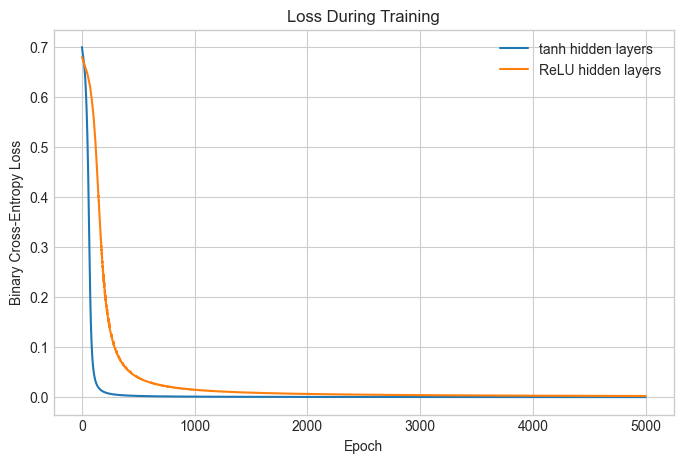

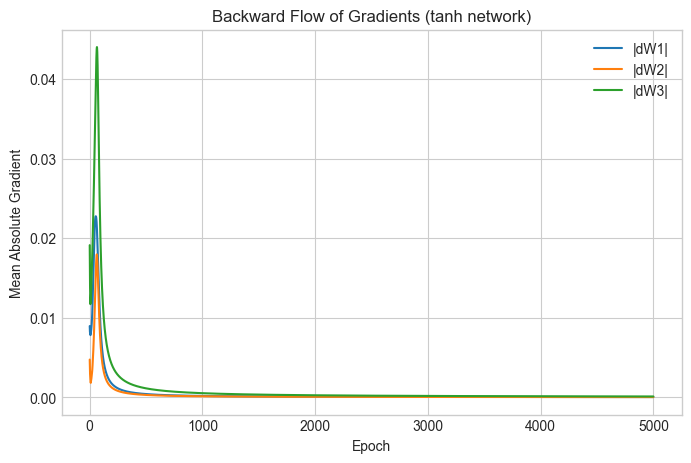

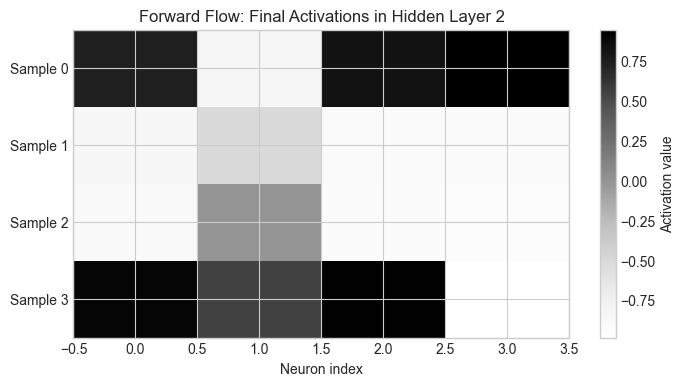


Quick observations:
- Final tanh loss: 0.000184
- Final ReLU loss: 0.002338
- In this small XOR example, tanh usually learns more smoothly than ReLU because the data is tiny and centered.
- The gradient plot helps show whether gradients stay healthy or start shrinking too much across layers.


In [14]:
# --- Challenge 2 Solution: Forward + Backpropagation from Scratch (NumPy) ---
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

# XOR dataset
X = np.array([[0, 0],
              [0, 1],
              [1, 0],
              [1, 1]], dtype=float)
y = np.array([[0],
              [1],
              [1],
              [0]], dtype=float)

def sigmoid(z):
    return 1 / (1 + np.exp(-z))

def sigmoid_derivative(a):
    return a * (1 - a)

def tanh(z):
    return np.tanh(z)

def tanh_derivative(a):
    return 1 - np.square(a)

def relu(z):
    return np.maximum(0, z)

def relu_derivative(z):
    return (z > 0).astype(float)

def binary_cross_entropy(y_true, y_pred):
    eps = 1e-8
    y_pred = np.clip(y_pred, eps, 1 - eps)
    return -np.mean(y_true * np.log(y_pred) + (1 - y_true) * np.log(1 - y_pred))

def initialize_parameters(input_size, h1_size, h2_size, output_size):
    return {
        "W1": np.random.randn(input_size, h1_size) * 0.5,
        "b1": np.zeros((1, h1_size)),
        "W2": np.random.randn(h1_size, h2_size) * 0.5,
        "b2": np.zeros((1, h2_size)),
        "W3": np.random.randn(h2_size, output_size) * 0.5,
        "b3": np.zeros((1, output_size)),
    }

def forward_propagation(X, params, hidden_activation="tanh"):
    Z1 = X @ params["W1"] + params["b1"]
    A1 = relu(Z1) if hidden_activation == "relu" else tanh(Z1)

    Z2 = A1 @ params["W2"] + params["b2"]
    A2 = relu(Z2) if hidden_activation == "relu" else tanh(Z2)

    Z3 = A2 @ params["W3"] + params["b3"]
    A3 = sigmoid(Z3)

    cache = {"X": X, "Z1": Z1, "A1": A1, "Z2": Z2, "A2": A2, "Z3": Z3, "A3": A3}
    return A3, cache

def backward_propagation(y_true, params, cache, hidden_activation="tanh"):
    m = y_true.shape[0]

    dZ3 = cache["A3"] - y_true
    dW3 = (cache["A2"].T @ dZ3) / m
    db3 = np.sum(dZ3, axis=0, keepdims=True) / m

    if hidden_activation == "relu":
        dZ2 = (dZ3 @ params["W3"].T) * relu_derivative(cache["Z2"])
        dZ1 = (dZ2 @ params["W2"].T) * relu_derivative(cache["Z1"])
    else:
        dZ2 = (dZ3 @ params["W3"].T) * tanh_derivative(cache["A2"])
        dZ1 = (dZ2 @ params["W2"].T) * tanh_derivative(cache["A1"])

    dW2 = (cache["A1"].T @ dZ2) / m
    db2 = np.sum(dZ2, axis=0, keepdims=True) / m
    dW1 = (cache["X"].T @ dZ1) / m
    db1 = np.sum(dZ1, axis=0, keepdims=True) / m

    grads = {"dW1": dW1, "db1": db1, "dW2": dW2, "db2": db2, "dW3": dW3, "db3": db3}
    return grads

def update_parameters(params, grads, learning_rate=0.5):
    for layer in [1, 2, 3]:
        params[f"W{layer}"] -= learning_rate * grads[f"dW{layer}"]
        params[f"b{layer}"] -= learning_rate * grads[f"db{layer}"]
    return params

def train_network(X, y, hidden_activation="tanh", learning_rate=0.5, epochs=5000):
    params = initialize_parameters(input_size=2, h1_size=4, h2_size=4, output_size=1)
    losses = []
    grad_history = {"dW1": [], "dW2": [], "dW3": []}

    for epoch in range(epochs):
        y_pred, cache = forward_propagation(X, params, hidden_activation=hidden_activation)
        loss = binary_cross_entropy(y, y_pred)
        grads = backward_propagation(y, params, cache, hidden_activation=hidden_activation)
        params = update_parameters(params, grads, learning_rate=learning_rate)

        losses.append(loss)
        grad_history["dW1"].append(np.mean(np.abs(grads["dW1"])))
        grad_history["dW2"].append(np.mean(np.abs(grads["dW2"])))
        grad_history["dW3"].append(np.mean(np.abs(grads["dW3"])))

    final_pred, final_cache = forward_propagation(X, params, hidden_activation=hidden_activation)
    return params, final_pred, final_cache, losses, grad_history

params_tanh, pred_tanh, cache_tanh, losses_tanh, grads_tanh = train_network(
    X, y, hidden_activation="tanh", learning_rate=0.5, epochs=5000
)

params_relu, pred_relu, cache_relu, losses_relu, grads_relu = train_network(
    X, y, hidden_activation="relu", learning_rate=0.1, epochs=5000
)

print("Final predictions with tanh hidden layers:")
print(np.round(pred_tanh, 4))
print("\nBinary predictions:")
print((pred_tanh >= 0.5).astype(int))
print("\nTrue labels:")
print(y.astype(int))

plt.figure(figsize=(8, 5))
plt.plot(losses_tanh, label="tanh hidden layers")
plt.plot(losses_relu, label="ReLU hidden layers")
plt.title("Loss During Training")
plt.xlabel("Epoch")
plt.ylabel("Binary Cross-Entropy Loss")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(grads_tanh["dW1"], label="|dW1|")
plt.plot(grads_tanh["dW2"], label="|dW2|")
plt.plot(grads_tanh["dW3"], label="|dW3|")
plt.title("Backward Flow of Gradients (tanh network)")
plt.xlabel("Epoch")
plt.ylabel("Mean Absolute Gradient")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(8, 4))
plt.imshow(cache_tanh["A2"], aspect="auto")
plt.colorbar(label="Activation value")
plt.yticks(range(len(X)), [f"Sample {i}" for i in range(len(X))])
plt.title("Forward Flow: Final Activations in Hidden Layer 2")
plt.xlabel("Neuron index")
plt.show()

print("\nQuick observations:")
print(f"- Final tanh loss: {losses_tanh[-1]:.6f}")
print(f"- Final ReLU loss: {losses_relu[-1]:.6f}")
print("- In this small XOR example, tanh usually learns more smoothly than ReLU because the data is tiny and centered.")
print("- The gradient plot helps show whether gradients stay healthy or start shrinking too much across layers.")

### Reflection

In this scratch implementation, I could clearly see the difference between forward propagation and backpropagation. During the forward pass, each layer transformed the input into a new representation, and the final sigmoid output produced the prediction. During backpropagation, the error moved backward through the network and generated gradients for each weight matrix. The loss curve showed that the model gradually learned the XOR pattern after many updates.

I also noticed that activation choice matters a lot. With the small XOR dataset, tanh gave smoother learning than ReLU in many runs because the values stayed more balanced around zero. The gradient-flow plot also helped me understand why deeper networks can become harder to train. When gradients get too small, earlier layers learn very slowly, which is part of the vanishing gradient problem. This exercise made the learning process feel much less like a black box because I could see how predictions, loss, gradients, and updates were all connected.


### Workshop Summary

Today we covered the essential theory and practice of Multi-Layered Perceptrons.

* **Core Concepts**: We learned that MLPs are inspired by the brain and are built from layers of artificial neurons.
* **Mechanism**: Each neuron performs a `weighted sum -> activation` calculation.
* **Learning**: The network learns through a two-step process of **Feedforward** (to predict) and **Backpropagation** (to correct errors).
* **Implementation**: We saw that while the code syntax for Keras, PyTorch, and TensorFlow is different, the underlying principles of defining, training, and evaluating a model are the same.

You now have a foundational understanding of one of the most important models in machine learning. Great work!
